# Demo 2: Local GTZAN + Local Suno Evaluation

This notebook keeps both datasets local:
- GTZAN audio is read from `data/genres_original`
- AI-generated Suno audio is read from `data/suno-audio` https://huggingface.co/datasets/humair025/suno-audio

It also avoids `import tensorflow.keras as keras` in the setup flow.
Instead, it uses a separate `import keras` cell after dependencies are installed, which is usually more reliable in notebook environments.

Before running anything, switch the notebook kernel to `Python (DS340 demo2)`.

In [1]:
import subprocess
import sys
from pathlib import Path

EXPECTED_KERNEL_PATH = Path.cwd() / ".venv" / "bin" / "python"
EXPECTED_PYTHON = EXPECTED_KERNEL_PATH.resolve()
print(f"Current kernel: {sys.executable}")
print(f"Expected kernel path: {EXPECTED_KERNEL_PATH}")

if Path(sys.executable).resolve() != EXPECTED_PYTHON:
    raise RuntimeError(
        "Wrong notebook kernel. In Jupyter, choose Kernel > Change Kernel > Python (DS340 demo2), then rerun this cell."
    )

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "pip",
        "setuptools",
        "wheel",
        "keras",
        "tensorflow",
        "librosa",
        "soundfile",
        "datasets",
        "scikit-learn",
        "pandas",
        "matplotlib",
        "ipykernel",
        "notebook",
    ],
    check=True,
)

print("Environment repair is complete. Restart the kernel before continuing.")

Current kernel: /Users/mingoosim/Desktop/DS340/Proejct/.venv/bin/python
Expected kernel path: /Users/mingoosim/Desktop/DS340/Proejct/.venv/bin/python
Environment repair is complete. Restart the kernel before continuing.


In [3]:
import importlib.util
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
EXPECTED_KERNEL_PATH = PROJECT_ROOT / ".venv" / "bin" / "python"
EXPECTED_PYTHON = EXPECTED_KERNEL_PATH.resolve()
EARLY_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "demo_2"
EARLY_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
EARLY_MPLCONFIG = EARLY_ARTIFACT_DIR / ".mplconfig"
EARLY_MPLCONFIG.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(EARLY_MPLCONFIG))
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

print(f"Python executable: {sys.executable}")
print(f"Expected project kernel path: {EXPECTED_KERNEL_PATH}")
print(sys.version)

if Path(sys.executable).resolve() != EXPECTED_PYTHON:
    raise RuntimeError(
        "Wrong notebook kernel. Switch to Python (DS340 demo2) before running the import cells."
    )

packages = ["keras", "tensorflow", "librosa", "datasets", "sklearn", "pandas", "matplotlib"]
for name in packages:
    print(name, importlib.util.find_spec(name) is not None)

print(f"MPLCONFIGDIR: {os.environ['MPLCONFIGDIR']}")
print(f"KERAS_BACKEND: {os.environ['KERAS_BACKEND']}")


Python executable: /Users/mingoosim/Desktop/DS340/Proejct/.venv/bin/python
Expected project kernel path: /Users/mingoosim/Desktop/DS340/Proejct/.venv/bin/python
3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:12) [Clang 14.0.6 ]
keras True
tensorflow True
librosa True
datasets True
sklearn True
pandas True
matplotlib True
MPLCONFIGDIR: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/demo_2/.mplconfig
KERAS_BACKEND: tensorflow


Use the repair cell above only when you need to reinstall packages. After that cell finishes, restart the kernel and rerun this notebook from the top.

In [4]:
import time

mods = ["keras", "tensorflow", "librosa", "datasets", "sklearn", "pandas", "matplotlib"]
for name in mods:
    t = time.time()
    mod = __import__(name)
    print(
        name,
        "version=", getattr(mod, "__version__", "unknown"),
        "file=", getattr(mod, "__file__", "unknown"),
        "import_sec=", round(time.time() - t, 2),
    )


keras version= 3.13.2 file= /Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/keras/__init__.py import_sec= 11.87
tensorflow version= 2.21.0 file= /Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/tensorflow/__init__.py import_sec= 0.0
librosa version= 0.11.0 file= /Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/librosa/__init__.py import_sec= 0.0


/Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets version= 4.8.3 file= /Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/datasets/__init__.py import_sec= 0.64
sklearn version= 1.8.0 file= /Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/sklearn/__init__.py import_sec= 0.0
pandas version= 3.0.1 file= /Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/pandas/__init__.py import_sec= 0.0
matplotlib version= 3.10.8 file= /Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/matplotlib/__init__.py import_sec= 0.0


In [5]:
import time

t = time.time()
import keras
print(f"Keras version: {keras.__version__}")
print(f"Keras import finished in {time.time() - t:.2f} seconds")

Keras version: 3.13.2
Keras import finished in 0.00 seconds


In [6]:
import json
import math
import os
import tempfile
from collections import Counter
from pathlib import Path

PROJECT_ROOT = Path.cwd()
PAPER_PDF = Path("/Users/mingoosim/Downloads/Music Genre Classification using Deep Learning (1)-2.pdf")
GTZAN_RAW_DIR = PROJECT_ROOT / "data" / "genres_original"
AI_DATA_ROOT = PROJECT_ROOT / "data" / "suno-audio"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "demo_2"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MPLCONFIG_DIR = ARTIFACT_DIR / ".mplconfig"
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

GTZAN_DATA_JSON = ARTIFACT_DIR / "gtzan_data.json"
MODEL_PATH = ARTIFACT_DIR / "paper_cnn.keras"
HISTORY_CSV = ARTIFACT_DIR / "gtzan_training_history.csv"
AI_JSON_PATH = ARTIFACT_DIR / "suno_ai_eval_mfcc.json"
AI_METADATA_CSV = ARTIFACT_DIR / "suno_ai_eval_metadata.csv"
AI_SEGMENT_RESULTS_CSV = ARTIFACT_DIR / "ai_segment_results.csv"
AI_TRACK_RESULTS_CSV = ARTIFACT_DIR / "ai_track_results.csv"

SAMPLE_RATE = 22050
TRACK_DURATION = 30
SAMPLES_PER_TRACK = SAMPLE_RATE * TRACK_DURATION
NUM_MFCC = 13
N_FFT = 2048
HOP_LENGTH = 512
NUM_SEGMENTS = 5

TEST_SIZE = 0.3
VALIDATION_SIZE = 0.2
LEARNING_RATE = 1e-4
EPOCHS = 30
BATCH_SIZE = 32
SEED = 42

REBUILD_GTZAN_JSON = not GTZAN_DATA_JSON.exists()
RETRAIN_MODEL = False
STRICT_SINGLE_LABEL = True
MAX_AI_TRACKS_PER_GENRE = 30
REBUILD_AI_FEATURES = False

print(f"Paper PDF exists: {PAPER_PDF.exists()} -> {PAPER_PDF}")
print(f"GTZAN raw folder exists: {GTZAN_RAW_DIR.exists()} -> {GTZAN_RAW_DIR}")
print(f"AI data root exists: {AI_DATA_ROOT.exists()} -> {AI_DATA_ROOT}")
print(f"Artifacts will be written to: {ARTIFACT_DIR}")
print(f"Will rebuild GTZAN MFCC JSON: {REBUILD_GTZAN_JSON}")

if not GTZAN_RAW_DIR.exists():
    raise FileNotFoundError(f"Could not find local GTZAN folder: {GTZAN_RAW_DIR}")

if not AI_DATA_ROOT.exists():
    raise FileNotFoundError(f"Could not find local Suno folder: {AI_DATA_ROOT}")

Paper PDF exists: True -> /Users/mingoosim/Downloads/Music Genre Classification using Deep Learning (1)-2.pdf
GTZAN raw folder exists: True -> /Users/mingoosim/Desktop/DS340/Proejct/data/genres_original
AI data root exists: True -> /Users/mingoosim/Desktop/DS340/Proejct/data/suno-audio
Artifacts will be written to: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/demo_2
Will rebuild GTZAN MFCC JSON: False


In [7]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Audio, load_from_disk
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

print("Non-Keras imports loaded successfully.")

Non-Keras imports loaded successfully.


In [9]:
def extract_mfcc_segments_from_file(file_path, num_mfcc=NUM_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, num_segments=NUM_SEGMENTS):
    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    samples_per_segment = int(SAMPLES_PER_TRACK / num_segments)
    expected_vectors = math.ceil(samples_per_segment / hop_length)

    segments = []
    for segment_idx in range(num_segments):
        start_sample = samples_per_segment * segment_idx
        finish_sample = start_sample + samples_per_segment

        mfcc = librosa.feature.mfcc(
            y=signal[start_sample:finish_sample],
            sr=sr,
            n_mfcc=num_mfcc,
            n_fft=n_fft,
            hop_length=hop_length,
        ).T

        if len(mfcc) == expected_vectors:
            segments.append(mfcc)

    return segments


def save_mfcc_from_folder(dataset_path, json_path, num_mfcc=NUM_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, num_segments=NUM_SEGMENTS):
    dataset_path = Path(dataset_path)
    data = {"mapping": [], "labels": [], "mfcc": []}

    for genre_idx, genre_dir in enumerate(sorted(p for p in dataset_path.iterdir() if p.is_dir())):
        data["mapping"].append(genre_dir.name)
        print(f"Processing GTZAN genre: {genre_dir.name}")

        for audio_file in sorted(genre_dir.iterdir()):
            if audio_file.suffix.lower() not in {".wav", ".mp3", ".au", ".flac", ".ogg", ".m4a"}:
                continue

            try:
                segments = extract_mfcc_segments_from_file(audio_file)
            except Exception as exc:
                print(f"SKIP (cannot read): {audio_file} | {type(exc).__name__}: {exc}")
                continue

            for mfcc in segments:
                data["mfcc"].append(mfcc.tolist())
                data["labels"].append(genre_idx)

    with open(json_path, "w") as fp:
        json.dump(data, fp)

    return data


def load_mfcc_json(json_path):
    with open(json_path, "r") as fp:
        data = json.load(fp)
    X = np.array(data["mfcc"], dtype=np.float32)
    y = np.array(data["labels"], dtype=np.int64)
    return data, X, y


def prepare_datasets_from_json(json_path, test_size=TEST_SIZE, validation_size=VALIDATION_SIZE, random_state=SEED):
    data, X, y = load_mfcc_json(json_path)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=validation_size, random_state=random_state)

    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    return data["mapping"], X_train, X_val, X_test, y_train, y_val, y_test


def build_paper_cnn(input_shape, num_classes):
    model = keras.Sequential()
    model.add(keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
    model.add(keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Conv2D(32, (3, 3), activation="relu"))
    model.add(keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Conv2D(32, (2, 2), activation="relu"))
    model.add(keras.layers.MaxPooling2D((2, 2), strides=(2, 2), padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(64, activation="relu"))
    model.add(keras.layers.Dropout(0.3))
    model.add(keras.layers.Dense(num_classes, activation="softmax"))
    return model


def plot_confusion_matrix(y_true, y_pred, label_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(label_names)))
    ax.set_yticks(range(len(label_names)))
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

Label order: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
X_train: (2796, 259, 13, 1) X_val: (699, 259, 13, 1) X_test: (1498, 259, 13, 1)
Epoch 1/30


/Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2285 - loss: 2.4962 - val_accuracy: 0.2661 - val_loss: 2.1063
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3537 - loss: 1.9682 - val_accuracy: 0.3677 - val_loss: 1.8002
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3959 - loss: 1.7340 - val_accuracy: 0.4478 - val_loss: 1.5957
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4406 - loss: 1.5734 - val_accuracy: 0.4607 - val_loss: 1.4928
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4778 - loss: 1.4784 - val_accuracy: 0.4807 - val_loss: 1.4340
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4975 - loss: 1.3958 - val_accuracy: 0.5050 - val_loss: 1.3816
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5204 - loss: 1.3313 - val_accuracy: 0.5179 - val_loss: 1.3350
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5451 - loss: 1.2722 - val_accuracy: 0.5265 - val_loss: 1.

,accuracy,loss,val_accuracy,val_loss
25,0.786481,0.630802,0.632332,0.999535
26,0.801144,0.617973,0.646638,0.993566
27,0.810443,0.587860,0.653791,0.982142
28,0.804721,0.587995,0.648069,0.984974
29,0.811516,0.545561,0.638054,0.985480


GTZAN test accuracy: 0.6115
              precision    recall  f1-score   support

       blues       0.62      0.58      0.60       162
   classical       0.83      0.89      0.86       151
     country       0.53      0.49      0.51       155
       disco       0.51      0.37      0.43       158
      hiphop       0.62      0.54      0.58       142
        jazz       0.64      0.72      0.68       146
       metal       0.61      0.87      0.72       140
         pop       0.65      0.72      0.68       141
      reggae       0.61      0.59      0.60       157
        rock       0.43      0.38      0.40       146

    accuracy                           0.61      1498
   macro avg       0.60      0.62      0.61      1498
weighted avg       0.60      0.61      0.60      1498



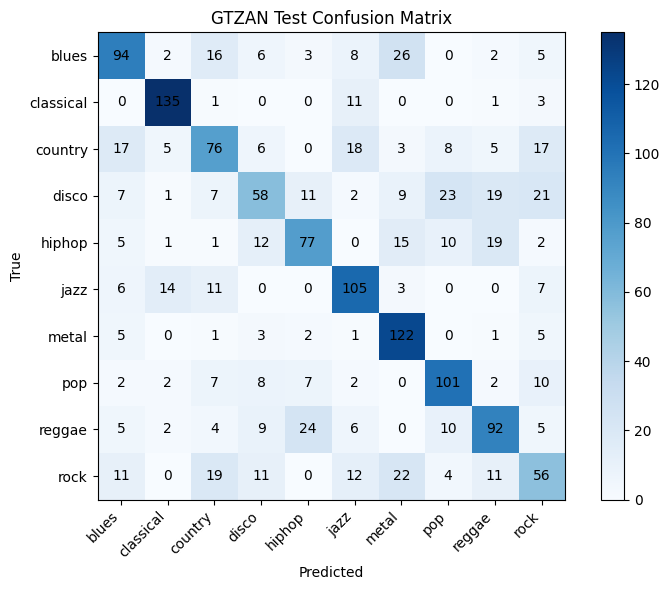

In [10]:
if REBUILD_GTZAN_JSON:
    print("Building GTZAN MFCC JSON from local audio...")
    save_mfcc_from_folder(GTZAN_RAW_DIR, GTZAN_DATA_JSON)

label_names, X_train, X_val, X_test, y_train, y_val, y_test = prepare_datasets_from_json(GTZAN_DATA_JSON)
genre_to_id = {genre: idx for idx, genre in enumerate(label_names)}

print("Label order:", label_names)
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

if MODEL_PATH.exists() and not RETRAIN_MODEL:
    model = keras.models.load_model(MODEL_PATH)
    history_df = pd.read_csv(HISTORY_CSV) if HISTORY_CSV.exists() else pd.DataFrame()
else:
    model = build_paper_cnn(X_train.shape[1:], len(label_names))
    optimiser = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimiser, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
    )
    model.save(MODEL_PATH)
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(HISTORY_CSV, index=False)

display(history_df.tail())

gtzan_test_loss, gtzan_test_acc = model.evaluate(X_test, y_test, verbose=0)
gtzan_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(f"GTZAN test accuracy: {gtzan_test_acc:.4f}")
print(classification_report(y_test, gtzan_test_pred, labels=list(range(len(label_names))), target_names=label_names, zero_division=0))
plot_confusion_matrix(y_test, gtzan_test_pred, label_names, "GTZAN Test Confusion Matrix")

Mapped AI tracks kept: 300


,tracks
mapped_genre,
blues,30
classical,30
country,30
disco,30
hiphop,30
jazz,30
metal,30
pop,30
reggae,30


/Users/mingoosim/Desktop/DS340/Proejct/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(


AI segment-level accuracy: 0.2296
AI segment-level macro F1: 0.2086
              precision    recall  f1-score   support

       blues       0.08      0.06      0.07       150
   classical       0.38      0.44      0.41       150
     country       0.26      0.21      0.23       150
       disco       0.28      0.20      0.23       150
      hiphop       0.39      0.37      0.38       150
        jazz       0.14      0.19      0.16       150
       metal       0.33      0.01      0.01       150
         pop       0.05      0.05      0.05       148
      reggae       0.26      0.59      0.36       150
        rock       0.18      0.18      0.18       150

    accuracy                           0.23      1498
   macro avg       0.24      0.23      0.21      1498
weighted avg       0.24      0.23      0.21      1498



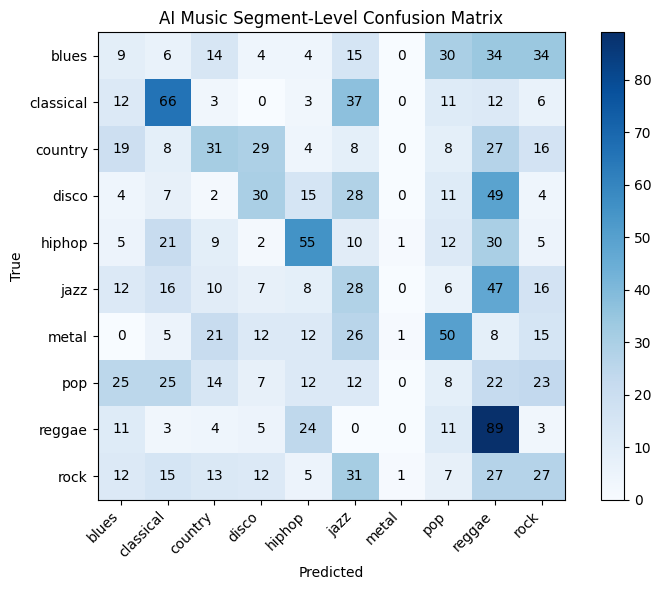

AI track-level accuracy: 0.2762
AI track-level macro F1: 0.2388


,track_id,title,true_label,true_label_id,pred_label_id,num_segments,pred_label
0,0000ea1f-027c-417d-9b45-42700040f10a,What Would My World Be Without You (Eurobeat S...,disco,3,8,5,reggae
1,000227ca-80d1-4675-9cb4-bfa65e0f04dd,The Tale of Esau,jazz,5,7,5,pop
2,0008089e-b2f9-44ee-9737-ced8b17d0fe8,Catwoman,rock,9,8,5,reggae
3,00093cde-3162-4f69-8e19-b51b74dcdd80,Neon Animals,hiphop,4,2,5,country
4,000f2bfa-a727-40d1-ae77-aa73cc49c014,,pop,7,7,10,pop
5,0011f300-eaef-4685-95ae-f33c67f9ace5,Rate Me or Hate Me,hiphop,4,2,5,country
6,00125341-502b-4edc-b417-46c7c9c8083e,Where Did Your Love Run Off To Trace Mix,disco,3,8,5,reggae
7,00138900-39c3-482b-8f84-045cf3bce8de,Dudas,jazz,5,3,5,disco
8,001458da-7133-4620-baeb-37e7337be4cb,Snap Map Trap,pop,7,4,5,hiphop
9,0017dadd-e9ce-4bcf-9d40-b907a801e5d3,YMIRAU feat.the9mice,hiphop,4,4,5,hiphop


In [11]:
GENRE_ALIASES = {
    "blues": {"blues"},
    "classical": {"classical"},
    "country": {"country"},
    "disco": {"disco"},
    "hiphop": {"hip hop", "hiphop"},
    "jazz": {"jazz"},
    "metal": {"metal"},
    "pop": {"pop"},
    "reggae": {"reggae"},
    "rock": {"rock"},
}


def normalize_tags(raw_tags):
    return {
        " ".join(part.strip().lower().split())
        for part in str(raw_tags).split(",")
        if part and part.strip()
    }


def map_tags_to_gtzan_genre(raw_tags, strict_single_label=True):
    tags = normalize_tags(raw_tags)
    matched = []
    for genre, aliases in GENRE_ALIASES.items():
        if any(alias in tags for alias in aliases):
            matched.append(genre)
    matched = sorted(set(matched))
    if len(matched) == 1:
        return matched[0]
    if strict_single_label:
        return None
    return matched[0] if matched else None


def collect_ai_eval_metadata(ai_root, max_ai_tracks_per_genre=MAX_AI_TRACKS_PER_GENRE, strict_single_label=STRICT_SINGLE_LABEL):
    records = []
    for batch_dir in sorted(p for p in ai_root.iterdir() if p.is_dir() and p.name.startswith("batch_")):
        try:
            ds = load_from_disk(str(batch_dir))
        except Exception:
            continue
        meta = ds.select_columns(["id", "title", "tags", "prompt", "duration", "model_name", "status"])
        for row_index in range(len(meta)):
            row = meta[row_index]
            mapped_genre = map_tags_to_gtzan_genre(row["tags"], strict_single_label=strict_single_label)
            if mapped_genre is None:
                continue
            records.append({
                "batch": batch_dir.name,
                "row_index": row_index,
                "track_id": str(row["id"]),
                "title": row["title"],
                "tags": row["tags"],
                "prompt": row["prompt"],
                "duration": row["duration"],
                "model_name": row["model_name"],
                "status": row["status"],
                "mapped_genre": mapped_genre,
            })
    metadata_df = pd.DataFrame(records).sort_values(["mapped_genre", "batch", "row_index"]).reset_index(drop=True)
    if max_ai_tracks_per_genre is not None and not metadata_df.empty:
        metadata_df = metadata_df.groupby("mapped_genre", group_keys=False).head(max_ai_tracks_per_genre).reset_index(drop=True)
    return metadata_df


def extract_mfcc_segments_from_audio_bytes(audio_bytes, suffix):
    with tempfile.NamedTemporaryFile(suffix=suffix or ".mp3", delete=True) as tmp_file:
        tmp_file.write(audio_bytes)
        tmp_file.flush()
        return extract_mfcc_segments_from_file(tmp_file.name)


def build_ai_eval_json(metadata_df, ai_root, output_json_path):
    data = {
        "mapping": label_names,
        "labels": [],
        "mfcc": [],
        "track_ids": [],
        "track_titles": [],
        "track_genres": [],
    }
    for batch_name, batch_rows in metadata_df.groupby("batch"):
        batch_ds = load_from_disk(str(ai_root / batch_name)).cast_column("audio", Audio(decode=False))
        for record in batch_rows.to_dict("records"):
            row = batch_ds[int(record["row_index"])]
            audio_info = row["audio"]
            suffix = Path(audio_info.get("path", "track.mp3")).suffix or ".mp3"
            segments = extract_mfcc_segments_from_audio_bytes(audio_info["bytes"], suffix)
            label_id = genre_to_id[record["mapped_genre"]]
            for mfcc in segments:
                data["mfcc"].append(mfcc.tolist())
                data["labels"].append(int(label_id))
                data["track_ids"].append(str(record["track_id"]))
                data["track_titles"].append(str(record["title"]))
                data["track_genres"].append(str(record["mapped_genre"]))
    with open(output_json_path, "w") as fp:
        json.dump(data, fp)
    return data


def load_ai_eval_json(json_path):
    with open(json_path, "r") as fp:
        data = json.load(fp)
    X = np.array(data["mfcc"], dtype=np.float32)[..., np.newaxis]
    y = np.array(data["labels"], dtype=np.int64)
    return data, X, y


ai_metadata_df = collect_ai_eval_metadata(AI_DATA_ROOT)
ai_metadata_df.to_csv(AI_METADATA_CSV, index=False)
print(f"Mapped AI tracks kept: {len(ai_metadata_df)}")
display(ai_metadata_df['mapped_genre'].value_counts().sort_index().to_frame('tracks'))

if AI_JSON_PATH.exists() and not REBUILD_AI_FEATURES:
    ai_eval_data, X_ai, y_ai = load_ai_eval_json(AI_JSON_PATH)
else:
    ai_eval_data = build_ai_eval_json(ai_metadata_df, AI_DATA_ROOT, AI_JSON_PATH)
    ai_eval_data, X_ai, y_ai = load_ai_eval_json(AI_JSON_PATH)

ai_pred = model.predict(X_ai, verbose=0).argmax(axis=1)
print(f"AI segment-level accuracy: {accuracy_score(y_ai, ai_pred):.4f}")
print(f"AI segment-level macro F1: {f1_score(y_ai, ai_pred, average='macro'):.4f}")
print(classification_report(y_ai, ai_pred, labels=list(range(len(label_names))), target_names=label_names, zero_division=0))
plot_confusion_matrix(y_ai, ai_pred, label_names, "AI Music Segment-Level Confusion Matrix")

segment_results_df = pd.DataFrame({
    'track_id': ai_eval_data['track_ids'],
    'title': ai_eval_data['track_titles'],
    'true_label_id': y_ai,
    'pred_label_id': ai_pred,
    'true_label': [label_names[idx] for idx in y_ai],
    'pred_label': [label_names[idx] for idx in ai_pred],
})
segment_results_df.to_csv(AI_SEGMENT_RESULTS_CSV, index=False)

track_results_df = (
    segment_results_df.groupby(['track_id', 'title', 'true_label'], as_index=False)
    .agg(
        true_label_id=('true_label_id', 'first'),
        pred_label_id=('pred_label_id', lambda series: Counter(series).most_common(1)[0][0]),
        num_segments=('pred_label_id', 'size'),
    )
)
track_results_df['pred_label'] = track_results_df['pred_label_id'].map(lambda idx: label_names[idx])
track_results_df.to_csv(AI_TRACK_RESULTS_CSV, index=False)

print(f"AI track-level accuracy: {accuracy_score(track_results_df['true_label_id'], track_results_df['pred_label_id']):.4f}")
print(f"AI track-level macro F1: {f1_score(track_results_df['true_label_id'], track_results_df['pred_label_id'], average='macro'):.4f}")
display(track_results_df.head(10))